In [1]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel, DDIMScheduler
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [3]:
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)


Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([8, 1, 8, 1, 3, 9, 6, 1])


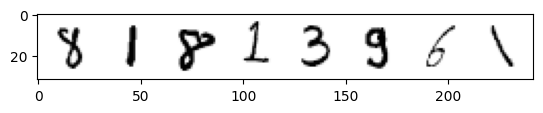

In [4]:
x, y = next(iter(train_dataloader))
print('Input shape:', x.shape)
print('Labels:', y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys');

In [5]:
class ConditionedUNet(nn.Module):
  def __init__(self, num_classes=10, class_emb_size=4):
    super().__init__()

    self.class_emb= nn.Embedding(num_classes, class_emb_size)
    self.model= UNet2DModel(
        sample_size=28,
        in_channels= 1 + class_emb_size,
        out_channels=1,
        layers_per_block= 2,
        block_out_channels=(32, 64, 64),
        down_block_types= (
            "DownBlock2D",
            "AttnDownBlock2D",
            "AttnDownBlock2D"
        ),
        up_block_types= (
            "AttnUpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D"
        )
    )

  def forward(self, x, t, class_labels):
    bs, ch, w, h= x.shape

    class_cond= self.class_emb(class_labels)
    class_cond = class_cond.view(bs, class_cond.shape[1], 1, 1).expand(bs, class_cond.shape[1], w, h)

    net_input= torch.cat((x, class_cond), 1)

    return self.model(net_input, t).sample

100%|██████████| 469/469 [03:20<00:00,  2.34it/s]


Epoch 0:
 Loss: 0.07522962098595684


100%|██████████| 469/469 [03:43<00:00,  2.10it/s]


Epoch 1:
 Loss: 0.047754059500023247


100%|██████████| 469/469 [04:18<00:00,  1.81it/s]


Epoch 2:
 Loss: 0.04453863099471592


100%|██████████| 469/469 [03:59<00:00,  1.96it/s]


Epoch 3:
 Loss: 0.0432011803695515


100%|██████████| 469/469 [03:51<00:00,  2.02it/s]

Epoch 4:
 Loss: 0.04189651784326222


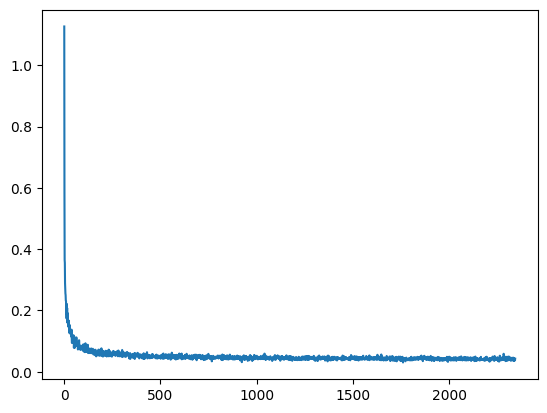

In [6]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

train_dataloader= DataLoader(dataset, batch_size= 128, shuffle=True)

num_epochs= 5

model= ConditionedUNet().to(device)
loss_fn= nn.MSELoss()
optimizer= torch.optim.Adam(model.parameters(), lr= 1e-3)

losses= []

for epoch in range(num_epochs):
  epoch_losses= 0.0
  for x,y in tqdm(train_dataloader):
    x= x.to(device) *2 - 1
    y= y.to(device)

    noise= torch.randn_like(x)
    timesteps= torch.randint(0, 999, (x.shape[0], )).long().to(device)
    noisy_x= noise_scheduler.add_noise(x, noise, timesteps)

    pred= model(noisy_x, timesteps, y)

    loss= loss_fn(pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_losses+= loss.item()
    losses.append(loss.item())
  avg_epoch_loss= epoch_losses / len(train_dataloader)
  print(f"Epoch {epoch}:\n Loss: {avg_epoch_loss}")

plt.plot(losses)

1000it [01:46,  9.36it/s]


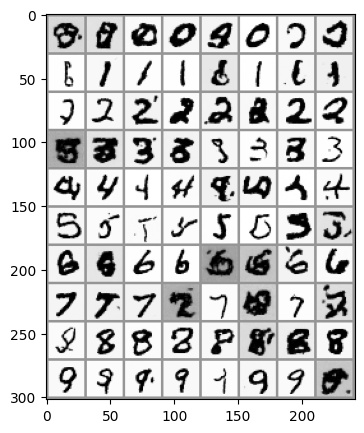

In [7]:
x = torch.randn(80, 1, 28, 28).to(device)
y = torch.tensor([[i]*8 for i in range(10)]).flatten().to(device)

for i, t in tqdm(enumerate(noise_scheduler.timesteps)):

    with torch.no_grad():
        residual = model(x, t, y)  

    x = noise_scheduler.step(residual, t, x).prev_sample

fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu().clip(-1, 1), nrow=8)[0], cmap='Greys')